In [1]:
!nvidia-smi

Fri Oct  2 13:12:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install -q ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.6/333.6 kB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 117.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 10.9 MB/s eta 0:00:00


In [3]:
import ultralytics

print(ultralytics.__version__)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
8.4.171


In [4]:
!pip install -q roboflow ultralytics

In [5]:
!pip install roboflow

from roboflow import Roboflow

rf = Roboflow(api_key="7pMaRVVNOSPO7lpdq9HU")

project = rf.workspace("sanyam-singh").project("pothole-detection-clean")

version = project.version(1)

dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to pothole-detection-clean-1 in yolov8:: 100%|██████████| 15747/15747 [00:02<00:00, 6715.71it/s] 


In [6]:
print(dataset.location)

/content/pothole-detection-clean-1


In [7]:
print(open("/content/pothole-detection-clean-1/data.yaml").read())

names:
- pothole
nc: 1
roboflow:
  license: MIT
  project: pothole-detection-clean
  url: https://universe.roboflow.com/sanyam-singh/pothole-detection-clean/dataset/1
  version: 1
  workspace: sanyam-singh
test: ../test/images
train: ../train/images
val: ../valid/images



In [8]:
import torch

print("GPU available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

GPU available: True
GPU: Tesla T4


In [9]:
from ultralytics import YOLO

model = YOLO("yolov8n.yaml")

In [10]:
results = model.train(
    data="/content/pothole-detection-clean-1/data.yaml",
    epochs=200,
    imgsz=512,
    batch=16,
    pretrained=False,
    device=0
)

Ultralytics 8.4.171 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pothole-detection-clean-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=None, opset=None, opti

KeyboardInterrupt: 

In [11]:
!ls /content/runs/detect/train/weights/

best.pt  last.pt


In [12]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train/weights/best.pt")

In [13]:
results = model.val(
    data="/content/pothole-detection-clean-1/data.yaml",
    imgsz=512,
    device=0
)

Ultralytics 8.4.171 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2035.3±743.9 MB/s, size: 38.2 KB)
val: Scanning /content/pothole-detection-clean-1/valid/labels.cache... 1843 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1843/1843 386.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 116/116 7.5it/s 15.4s
                   all       1843       4932      0.798      0.665      0.748      0.449
Speed: 0.8ms preprocess, 2.8ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /content/runs/detect/val


In [ ]:
metrics = model.val()

Ultralytics 8.4.159 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1306.6±578.1 MB/s, size: 86.7 KB)
val: Scanning /content/smart-pothole-detection-1/valid/labels.cache... 617 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 617/617 136.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 5.0it/s 7.9s
                   all        617       1845      0.781      0.622      0.717      0.428
Speed: 1.4ms preprocess, 4.2ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/detect/val


In [14]:
print("Precision:", results.box.mp)
print("Recall:", results.box.mr)
print("mAP50:", results.box.map50)
print("mAP50-95:", results.box.map)

Precision: 0.7978850946284922
Recall: 0.6654501216545012
mAP50: 0.7482850099733536
mAP50-95: 0.44908584689491676


In [16]:
import os

print(os.listdir("/content/pothole-detection-clean-1"))

['valid', 'train', 'test', 'data.yaml', 'README.dataset.txt', 'README.roboflow.txt']


In [18]:
res = model.predict(
    source="/content/pothole-detection-clean-1/test/images",
    imgsz=512,
    conf=0.25,
    save=True
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1020 /content/pothole-detection-clean-1/test/images/0004_jpg.rf.8818262b383ba1ee18c4d994e670a28e.jpg: 512x512 2 potholes, 10.5ms
image 2/1020 /content/pothole-detection-clean-1/test/images/0040_jpg.rf.f2d87b7fd5a4407350e9e2a2d27a5077.jpg: 512x512 3 potholes, 11.3ms
image 3/1020 /content/pothole-detection-clean-1/test/images/0041_jpg.rf.3defb74cc201655285c2fad567f95717.jpg: 512x512 3 potholes, 13.0ms
image 4/1020 /content/pothole-detection-clean-1/

Total predicted images: 1020


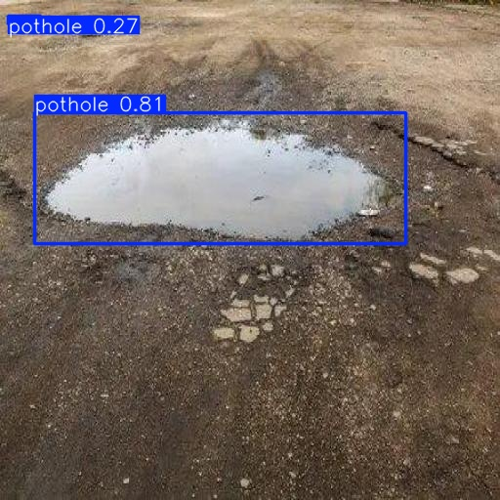

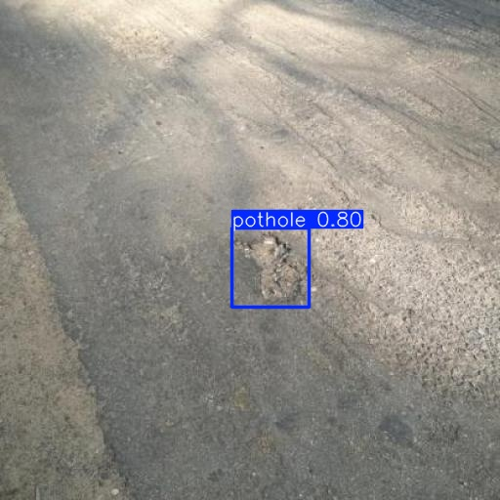

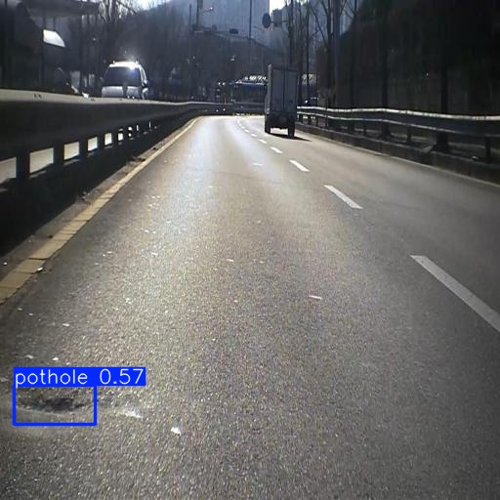

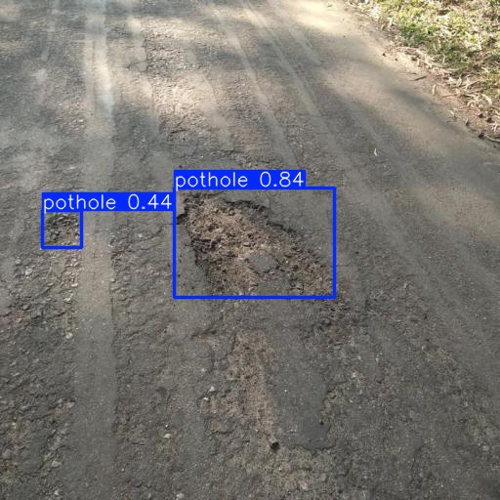

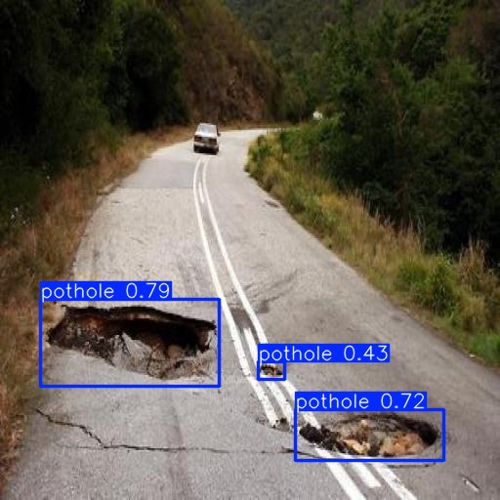

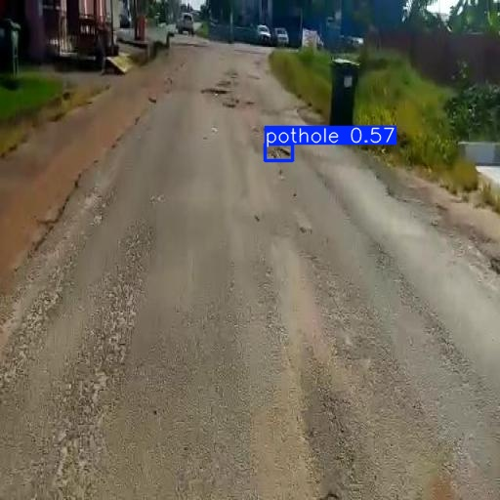

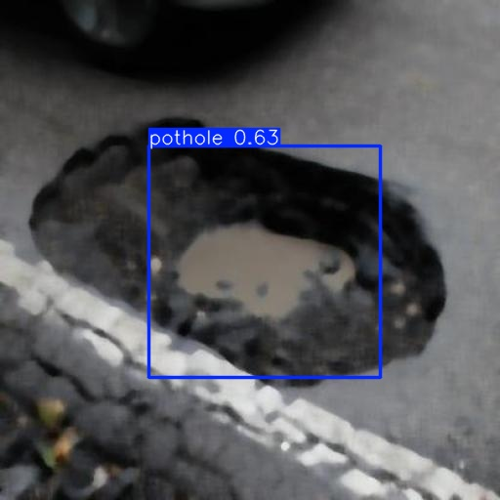

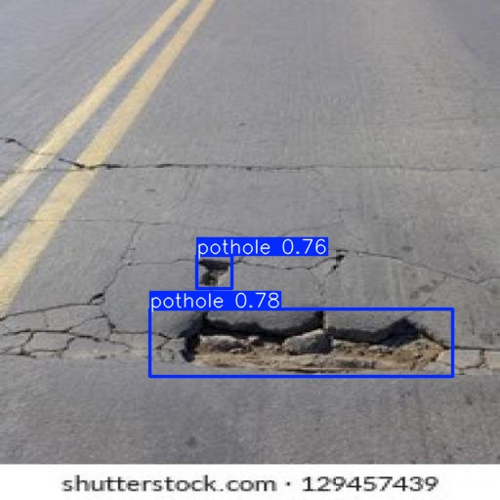

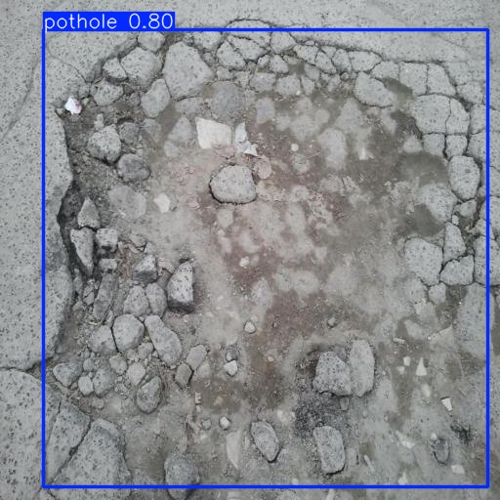

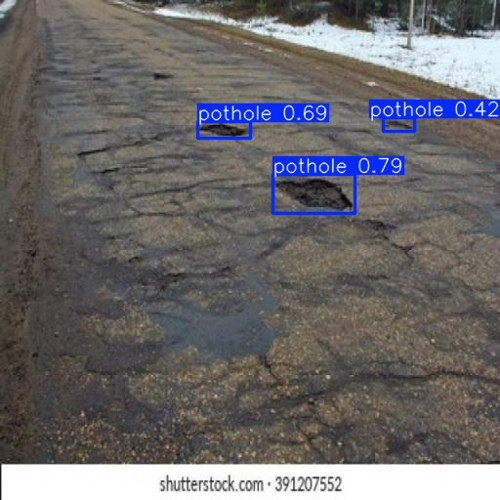

In [19]:
from IPython.display import display
from PIL import Image
import os

pred_dir = "/content/runs/detect/predict"

images = [
    f for f in os.listdir(pred_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Total predicted images:", len(images))

for img_name in images[:10]:
    display(Image.open(os.path.join(pred_dir, img_name)).resize((500, 500)))

Predicted images: 178


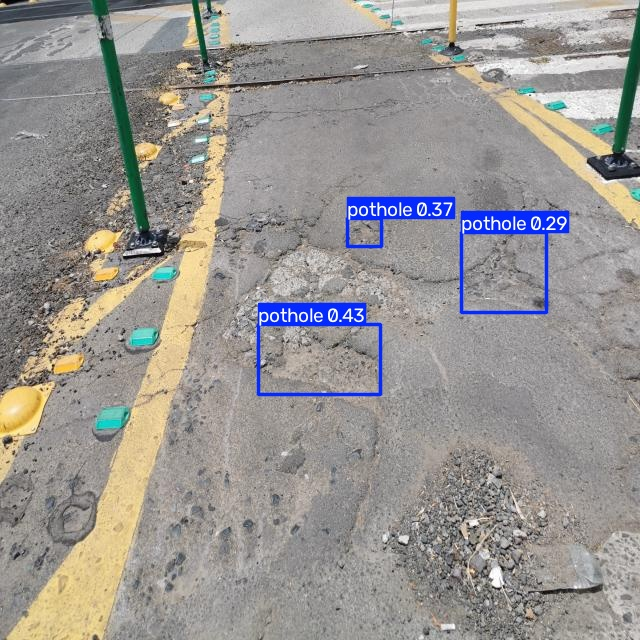

In [ ]:
import glob
from IPython.display import Image, display

images = glob.glob("runs/detect/predict/*.jpg")

print("Predicted images:", len(images))

display(Image(filename=images[0]))

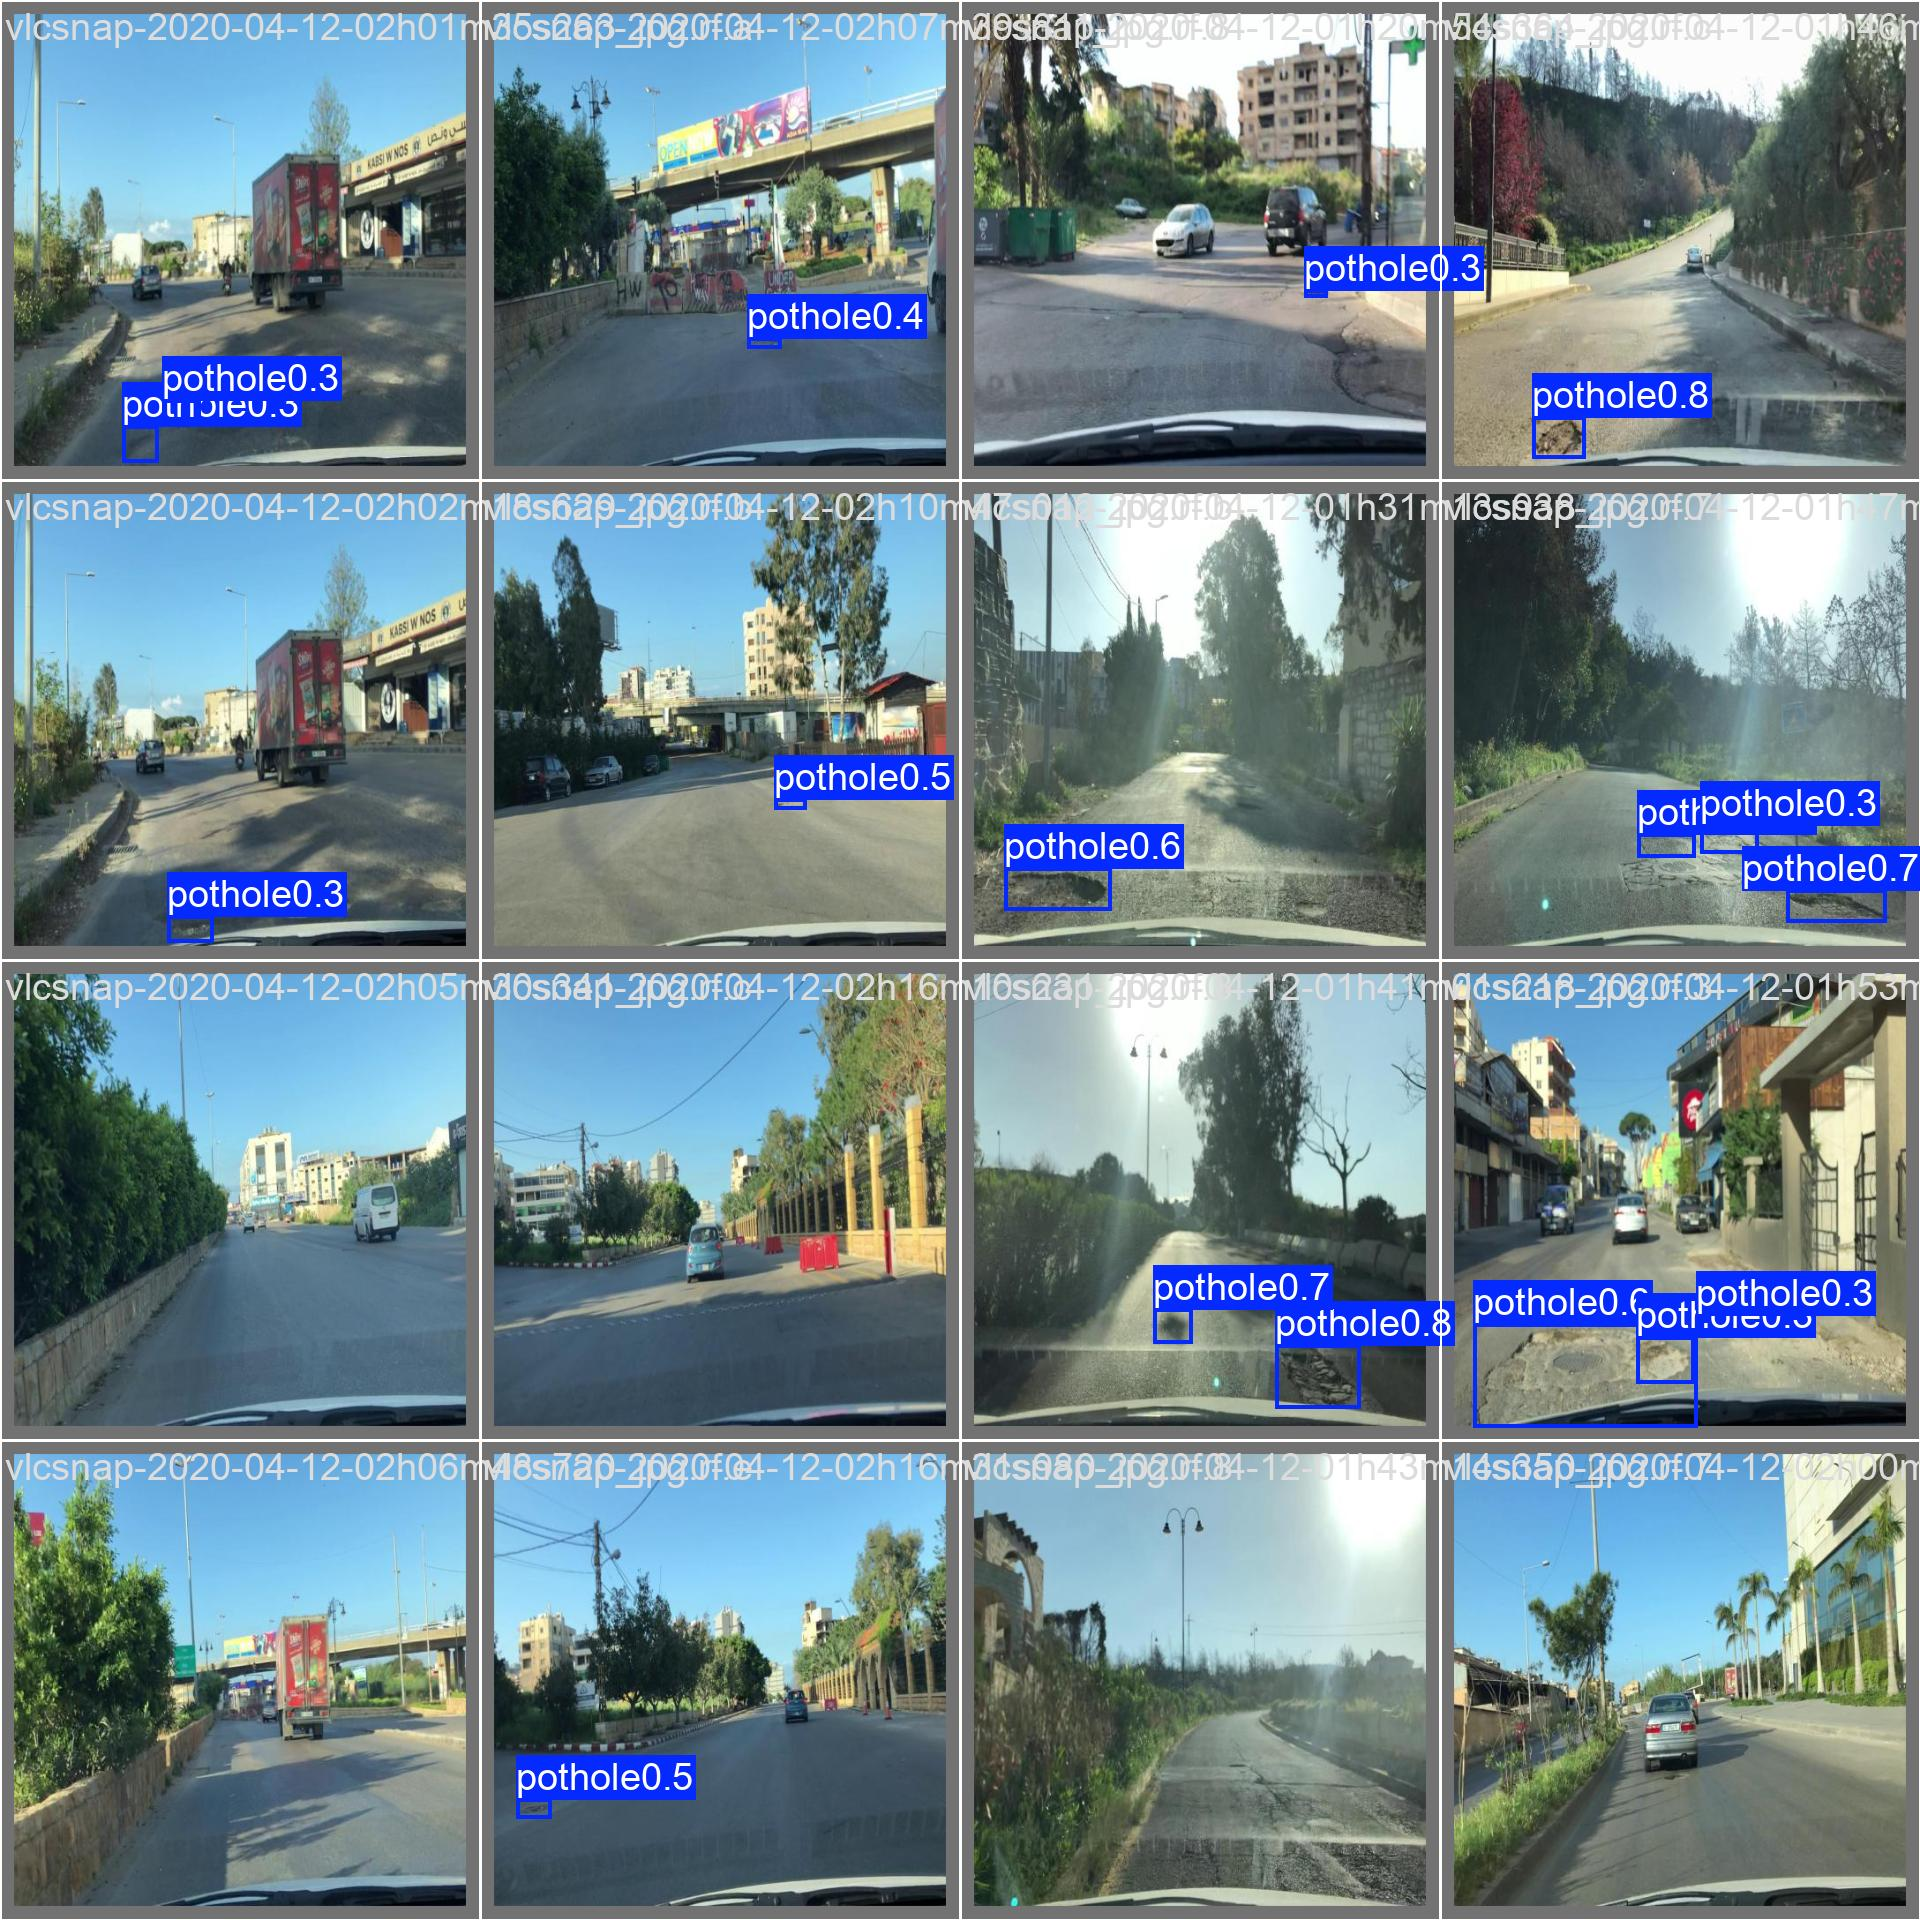

In [20]:
from IPython.display import Image, display

display(Image(filename="runs/detect/val/val_batch0_pred.jpg"))

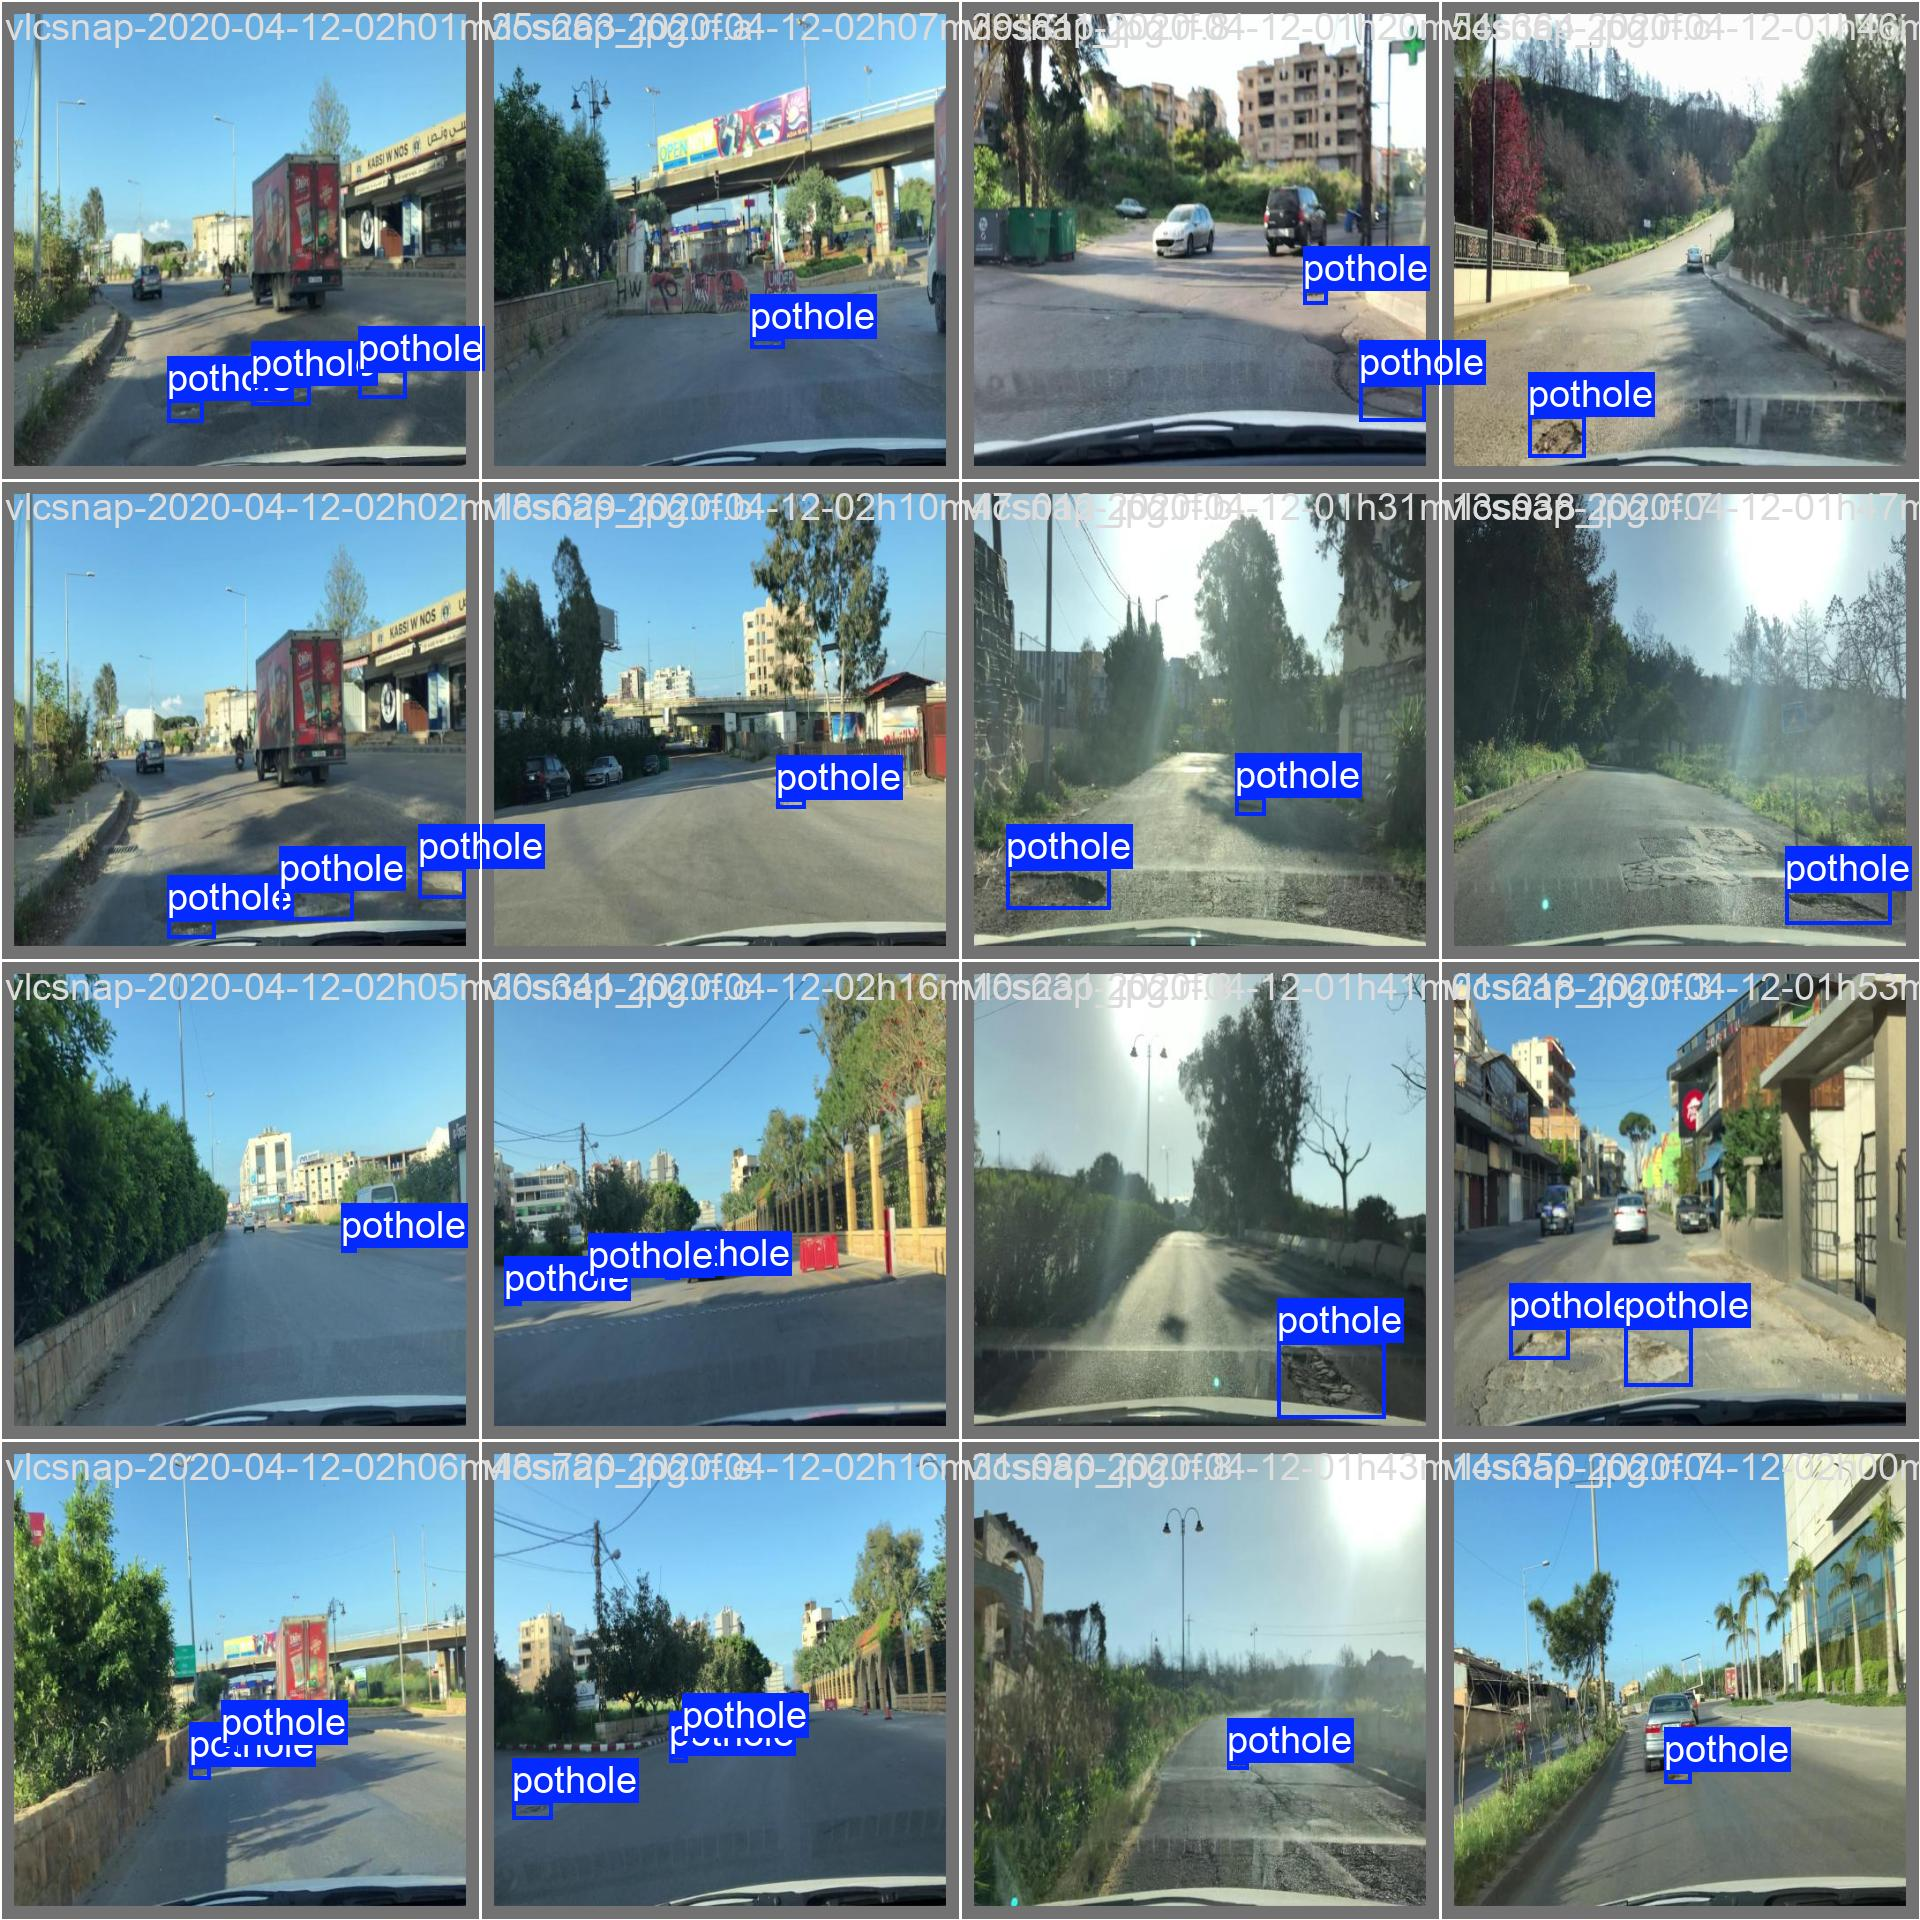

In [21]:
from IPython.display import Image, display

display(Image(filename="runs/detect/val/val_batch0_labels.jpg"))